# Phase 7 — Per-Product Results Table & Forecast Cards

Builds `data/processed/results_by_product.parquet` and
`outputs/forecasts/forecast_by_product.csv` with one row per product, then
generates forecast cards (history + 12-week served forecast) for 7
representative products (Figs 33–39).

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.float_format", "{:.4f}".format)

FIG_DIR  = ROOT / "outputs" / "figures"
FCST_DIR = ROOT / "outputs" / "forecasts"
FIG_DIR.mkdir(parents=True, exist_ok=True)
FCST_DIR.mkdir(parents=True, exist_ok=True)
DPI = 140

STYLE = {
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.size":        9,
}
plt.rcParams.update(STYLE)

# Champion model per (abc_class × demand_class) — from Phase 6 evaluation
CHAMPIONS = {
    ("A", "Smooth"):        "Naive",
    ("A", "Intermittent"):  "LightGBM",
    ("A", "Erratic"):       "Naive",
    ("A", "Lumpy"):         "LightGBM",
    ("A", "Too sparse"):    "Naive",
    ("B", "Smooth"):        "Naive",
    ("B", "Intermittent"):  "LightGBM",
    ("B", "Erratic"):       "Naive",
    ("B", "Lumpy"):         "CrostonOptimized",
    ("B", "Too sparse"):    "Naive",
    ("C", "Smooth"):        "Naive",
    ("C", "Intermittent"):  "LightGBM",
    ("C", "Erratic"):       "Naive",
    ("C", "Lumpy"):         "LightGBM",
    ("C", "Too sparse"):    "WindowAverage",
}

MODEL_COLS = ["LightGBM", "Naive", "SeasonalNaive", "WindowAverage",
              "CrostonClassic", "CrostonOptimized", "CrostonSBA", "TSB"]

TEST_ORIGIN  = pd.Timestamp("2025-06-16")
VALID_START  = pd.Timestamp("2025-03-31")
print("Setup OK")

Setup OK


In [2]:
# ── Load raw data ──────────────────────────────────────────────────────────────
wp  = pd.read_parquet(ROOT / "data/processed/weekly_product.parquet")
seg = pd.read_parquet(ROOT / "data/processed/product_segments.parquet")
pb  = pd.read_parquet(ROOT / "data/processed/preds_baselines.parquet")
pg  = pd.read_parquet(ROOT / "data/processed/preds_global.parquet")
wpc = pd.read_parquet(ROOT / "data/processed/weekly_product_country.parquet")

wp["week_start"]  = pd.to_datetime(wp["week_start"])
pb["target_week"] = pd.to_datetime(pb["target_week"])
pg["target_week"] = pd.to_datetime(pg["target_week"])
wpc["week_start"] = pd.to_datetime(wpc["week_start"])

# ── Filter global model to fixed-origin TEST predictions ──────────────────────
pg["origin_week"] = pg["target_week"] - pd.to_timedelta(
    pg["horizon"].astype(int) * 7, unit="D"
)
g_test = (
    pg[(pg["split"] == "test") & (pg["origin_week"] == TEST_ORIGIN)]
    [["ProductID", "target_week", "horizon", "y_true", "y_pred"]]
    .rename(columns={"y_pred": "LightGBM"})
    .copy()
)

# ── Join baselines + LightGBM into one TEST prediction table ──────────────────
b_test = pb[pb["split"] == "test"].copy()
all_test = b_test.merge(
    g_test[["ProductID", "target_week", "horizon", "LightGBM"]],
    on=["ProductID", "target_week", "horizon"], how="left"
)

# ── Assign champion model and served forecast ─────────────────────────────────
seg["champion_model"] = seg.apply(
    lambda r: CHAMPIONS.get((r["abc_class"], r["demand_class"]), "LightGBM"), axis=1
)
all_test = all_test.merge(
    seg[["ProductID", "abc_class", "demand_class", "route", "champion_model"]],
    on="ProductID", how="left"
)

all_test["served_fcst"] = np.nan
for m in MODEL_COLS:
    mask = all_test["champion_model"] == m
    if m in all_test.columns:
        all_test.loc[mask, "served_fcst"] = all_test.loc[mask, m].values

print(f"Aligned TEST table: {all_test.shape[0]:,} rows, {all_test['ProductID'].nunique():,} products")
print(f"NaN served_fcst: {all_test['served_fcst'].isna().sum()}")

Aligned TEST table: 155,448 rows, 12,954 products
NaN served_fcst: 0


In [3]:
# ── Pivot served forecast to wide (one row per product) ───────────────────────
fcst_wide = all_test.pivot_table(
    index="ProductID", columns="horizon",
    values="served_fcst", aggfunc="first"
)
fcst_wide.columns = [f"fcst_w{int(h)}" for h in fcst_wide.columns]
fcst_wide["fcst_12wk_total"] = fcst_wide[[f"fcst_w{h}" for h in range(1, 13)]].sum(axis=1)
fcst_wide = fcst_wide.reset_index()

# ── recent_avg_weekly: mean weekly qty in the 12 weeks ending at TEST_ORIGIN ──
hist_12w = wp[
    (wp["week_start"] >= TEST_ORIGIN - pd.Timedelta(weeks=11)) &
    (wp["week_start"] <= TEST_ORIGIN)
]
recent_avg = (
    hist_12w.groupby("ProductID")["qty"]
    .mean()
    .round(2)
    .rename("recent_avg_weekly")
    .reset_index()
)

# ── active_week_rate: fraction of panel weeks with demand > 0 ─────────────────
seg["active_week_rate"] = (
    seg["n_active_weeks"] / seg["panel_weeks"]
).round(4)

# ── top_country: country with most total qty over all history ─────────────────
top_country = (
    wpc.groupby(["ProductID", "Country"])["qty"].sum()
    .reset_index()
    .sort_values(["ProductID", "qty"], ascending=[True, False])
    .drop_duplicates("ProductID")
    .rename(columns={"Country": "top_country"})
    [["ProductID", "top_country"]]
)

# ── test_mase: per-product MASE on served forecast (evaluable products only) ──
# Denominator: mean |y[t] - y[t-1]| from training history (before VALID_START)
wp_train = wp[wp["week_start"] < VALID_START].sort_values(["ProductID", "week_start"]).copy()
wp_train["naive_err"] = wp_train.groupby("ProductID")["qty"].diff().abs()
denoms = wp_train.groupby("ProductID")["naive_err"].mean().replace(0.0, np.nan)

all_test["abs_err"] = np.abs(all_test["y_true"].astype(float) - all_test["served_fcst"].astype(float))
prod_mae = all_test.groupby("ProductID")["abs_err"].mean().rename("mae_p")
prod_denom = prod_mae.index.map(denoms)
prod_mase = (
    (prod_mae / prod_denom)
    .where(prod_denom.notna() & (prod_denom > 0))
    .round(4)
    .rename("test_mase")
    .reset_index()
)

print(f"Denominators: {denoms.notna().sum():,} valid | {denoms.isna().sum():,} excluded")
print(f"test_mase computed for {prod_mase['test_mase'].notna().sum():,} products")

Denominators: 12,223 valid | 64 excluded
test_mase computed for 12,223 products


In [4]:
# ── Assemble results_by_product ────────────────────────────────────────────────
results = (
    seg[["ProductID", "abc_class", "demand_class", "route",
         "champion_model", "active_week_rate", "n_active_weeks",
         "total_qty", "first_sale_week"]].copy()
    .merge(fcst_wide, on="ProductID", how="left")
    .merge(recent_avg, on="ProductID", how="left")
    .merge(prod_mase, on="ProductID", how="left")
    .merge(top_country, on="ProductID", how="left")
)

# Sort: abc_class (A first), then test_mase ascending (best first within each class)
abc_order = {"A": 0, "B": 1, "C": 2}
results["_abc_sort"] = results["abc_class"].map(abc_order)
results = results.sort_values(["_abc_sort", "test_mase"]).drop(columns="_abc_sort")
results = results.reset_index(drop=True)

# ── Save ──────────────────────────────────────────────────────────────────────
parquet_path = ROOT / "data/processed/results_by_product.parquet"
csv_path     = ROOT / "outputs/forecasts/forecast_by_product.csv"

results.to_parquet(parquet_path, index=False)

# CSV: just the key columns + forecasts (keep file manageable)
csv_cols = (
    ["ProductID", "abc_class", "demand_class", "route", "champion_model",
     "total_qty", "recent_avg_weekly", "active_week_rate", "test_mase", "top_country"]
    + [f"fcst_w{h}" for h in range(1, 13)]
    + ["fcst_12wk_total"]
)
results[csv_cols].to_csv(csv_path, index=False, float_format="%.4f")

print(f"results_by_product: {results.shape[0]:,} rows × {results.shape[1]} cols")
print(f"Saved → {parquet_path.relative_to(ROOT)}")
print(f"Saved → {csv_path.relative_to(ROOT)}")

results_by_product: 13,707 rows × 25 cols
Saved → data/processed/results_by_product.parquet
Saved → outputs/forecasts/forecast_by_product.csv


In [5]:
# ── Print table summary (sorted by abc_class then test_mase) ──────────────────
print_cols = ["ProductID", "abc_class", "demand_class", "champion_model",
              "total_qty", "recent_avg_weekly", "fcst_12wk_total",
              "test_mase", "active_week_rate", "top_country"]

for abc in ["A", "B", "C"]:
    sub = results[results["abc_class"] == abc][print_cols]
    n_eval = sub["test_mase"].notna().sum()
    print(f"\n{'='*80}")
    print(f"ABC-{abc}  ({len(sub):,} products, {n_eval:,} evaluable)")
    print(f"{'='*80}")
    if abc == "A":
        print(sub.to_string(index=False))
    elif abc == "B":
        print(sub.head(20).to_string(index=False))
        print(f"  ... {len(sub)-20:,} more B products ...")
    else:
        print(sub.head(10).to_string(index=False))
        print(f"  ... {len(sub)-10:,} more C products ...")


ABC-A  (677 products, 668 evaluable)
ProductID abc_class demand_class champion_model   total_qty  recent_avg_weekly  fcst_12wk_total  test_mase  active_week_rate            top_country
19835-095         A      Erratic          Naive   4238.0000             0.0000           0.0000     0.0000            0.0377            NEW ZEALAND
36173-097         A       Smooth          Naive  46341.0000             0.0000           0.0000     0.0000            0.0370                 RUSSIA
40932-092         A       Smooth          Naive   4222.0000             0.0000           0.0000     0.0000            0.0129            NEW ZEALAND
47928-084         A   Too sparse          Naive   3148.0000             0.0000           0.0000     0.0000            0.0167                LEBANON
49469-044         A       Smooth          Naive  11070.0000             0.0000           0.0000     0.0000            0.0130                 RUSSIA
68447-087         A       Smooth          Naive   4207.0000             0.

In [6]:
# ── Select 7 products for forecast cards ──────────────────────────────────────
# 1. Top 3 A-products by total lifetime qty
top3_a = results[results["abc_class"] == "A"].nlargest(3, "total_qty")["ProductID"].tolist()

# 2. 1 typical B-product (median test_mase among evaluable B-class)
b_eval = results[(results["abc_class"] == "B") & results["test_mase"].notna()].copy()
b_eval = b_eval.sort_values("test_mase").reset_index(drop=True)
typical_b = b_eval.iloc[len(b_eval) // 2]["ProductID"]

# 3. 1 sparse C-product (lowest active_week_rate with at least 1 forecast week)
sparse_c = (
    results[
        (results["abc_class"] == "C") &
        (results["active_week_rate"] < 0.05) &
        results["fcst_12wk_total"].notna()
    ]
    .sort_values("active_week_rate")
    .iloc[0]["ProductID"]
)

# 4. 2 worst-MASE A/B products (highest test_mase, so model struggled most)
worst2_ab = (
    results[results["abc_class"].isin(["A", "B"]) & results["test_mase"].notna()]
    .nlargest(2, "test_mase")["ProductID"]
    .tolist()
)

card_products = top3_a + [typical_b, sparse_c] + worst2_ab
card_labels   = (
    [f"Top-A #{i+1}" for i in range(3)]
    + ["Typical-B", "Sparse-C"]
    + ["Worst-MASE #1", "Worst-MASE #2"]
)

print("Forecast card products:")
for lbl, pid in zip(card_labels, card_products):
    row = results[results["ProductID"] == pid].iloc[0]
    print(f"  [{lbl:>16s}]  {pid}  ABC-{row['abc_class']} / "
          f"{row['demand_class']:<14s} champion={row['champion_model']:<18s} "
          f"MASE={row['test_mase']:.4f}" if pd.notna(row['test_mase'])
          else f"  [{lbl:>16s}]  {pid}  ABC-{row['abc_class']} / "
               f"{row['demand_class']:<14s} champion={row['champion_model']:<18s} "
               f"MASE=N/A")

Forecast card products:
  [        Top-A #1]  68877-087  ABC-A / Lumpy          champion=LightGBM           MASE=0.4759
  [        Top-A #2]  53064-028  ABC-A / Intermittent   champion=LightGBM           MASE=0.6124
  [        Top-A #3]  14898-083  ABC-A / Intermittent   champion=LightGBM           MASE=0.4330
  [       Typical-B]  41884-086  ABC-B / Lumpy          champion=CrostonOptimized   MASE=0.5436
  [        Sparse-C]  57955-024  ABC-C / Too sparse     champion=WindowAverage      MASE=N/A
  [   Worst-MASE #1]  53704-013  ABC-B / Lumpy          champion=CrostonOptimized   MASE=1188.4444
  [   Worst-MASE #2]  11766-014  ABC-B / Lumpy          champion=CrostonOptimized   MASE=111.0690


In [7]:
# ── Forecast card generator ────────────────────────────────────────────────────

CHAMP_COLOR = {
    "LightGBM":        "#2E86AB",
    "Naive":           "#888888",
    "SeasonalNaive":   "#AAAAAA",
    "WindowAverage":   "#CCCCCC",
    "CrostonOptimized":"#D4832A",
    "CrostonSBA":      "#C05F20",
    "TSB":             "#A63D0F",
}

def fmt(v, precision=1, suffix=""):
    return f"{v:.{precision}f}{suffix}" if pd.notna(v) else "N/A"


def plot_card(pid, label, fig_num, show=True):
    row = results[results["ProductID"] == pid].iloc[0]
    champ_col = CHAMP_COLOR.get(row["champion_model"], "#2E86AB")

    # ── History ────────────────────────────────────────────────────────────────
    hist = wp[wp["ProductID"] == pid].sort_values("week_start")
    # Show at most 78 weeks of history (1.5 years) before TEST_ORIGIN
    hist_plot = hist[
        (hist["week_start"] >= TEST_ORIGIN - pd.Timedelta(weeks=78)) &
        (hist["week_start"] <= TEST_ORIGIN)
    ]

    # ── Test actuals ───────────────────────────────────────────────────────────
    test_act = (
        all_test[all_test["ProductID"] == pid]
        .sort_values("target_week")
        [["target_week", "y_true", "served_fcst"]]
    )

    # ── Forecast values from results table ─────────────────────────────────────
    fcst_weeks = [TEST_ORIGIN + pd.Timedelta(weeks=h) for h in range(1, 13)]
    fcst_vals  = [row.get(f"fcst_w{h}", np.nan) for h in range(1, 13)]

    # ── Layout: left (KPI box) + right (time series) ───────────────────────────
    fig = plt.figure(figsize=(13, 4.2))
    gs  = GridSpec(1, 5, figure=fig, wspace=0.05)
    ax_kpi = fig.add_subplot(gs[0])
    ax_ts  = fig.add_subplot(gs[1:])

    # KPI panel (no axes)
    ax_kpi.set_xlim(0, 1); ax_kpi.set_ylim(0, 1); ax_kpi.set_axis_off()
    ax_kpi.add_patch(mpatches.FancyBboxPatch(
        (0.02, 0.02), 0.96, 0.96,
        boxstyle="round,pad=0.02", facecolor="#f7f7f7", edgecolor="#cccccc", lw=1
    ))
    kpi_lines = [
        (f"{pid}",                                   True,  11),
        (f"ABC: {row['abc_class']}",                 False,  9),
        (f"Demand: {row['demand_class']}",           False,  9),
        (f"Route: {row['route']}",                   False,  8),
        (f"Champion: {row['champion_model']}",       False,  9),
        (f"Top Ctry: {row.get('top_country','N/A')}",False,  8),
        ("",                                         False,  6),
        (f"12wk fcst total:",                        False,  8),
        (f"  {fmt(row['fcst_12wk_total'], 0)} units",True,  10),
        (f"Recent avg/wk:",                          False,  8),
        (f"  {fmt(row['recent_avg_weekly'], 1)}",    True,  10),
        (f"Test MASE:",                              False,  8),
        (f"  {fmt(row['test_mase'], 3)}",            True,  10),
        (f"Active rate:",                            False,  8),
        (f"  {fmt(row['active_week_rate']*100, 1)}%",True,  10),
    ]
    y_pos = 0.96
    for text, bold, fsize in kpi_lines:
        ax_kpi.text(0.08, y_pos, text,
                    transform=ax_kpi.transAxes, fontsize=fsize,
                    fontweight="bold" if bold else "normal",
                    va="top", color="#222")
        y_pos -= 0.064 if text else 0.025

    # Time-series panel
    if len(hist_plot) > 0:
        ax_ts.bar(hist_plot["week_start"], hist_plot["qty"],
                  width=5.5, color="#C8D8E8", alpha=0.85, label="History")

    if len(test_act) > 0:
        ax_ts.plot(test_act["target_week"], test_act["y_true"],
                   "o--", color="#555", markersize=4, linewidth=1.2,
                   alpha=0.7, label="Test actual")

    ax_ts.plot(fcst_weeks, fcst_vals, "s-", color=champ_col,
               markersize=5, linewidth=2.2,
               label=f"Forecast ({row['champion_model']})")

    ax_ts.axvline(TEST_ORIGIN, color="#E8A838", linewidth=1.6,
                  linestyle="--", alpha=0.85, label="Forecast origin (2025-06-16)")

    ax_ts.set_xlabel("Week")
    ax_ts.set_ylabel("Sales Qty")
    ax_ts.set_title(
        f"[{label}]  {pid} — ABC-{row['abc_class']} / {row['demand_class']} "
        f"| Champion: {row['champion_model']}",
        fontsize=10
    )
    ax_ts.legend(fontsize=8, framealpha=0.8, loc="upper left")
    ax_ts.tick_params(axis="x", rotation=20)

    fig.suptitle(
        f"Fig {fig_num}  Forecast card: {pid}",
        fontsize=10, y=1.01
    )
    fig.tight_layout()
    out = FIG_DIR / f"{fig_num:02d}_card_{pid.replace('-','_')}.png"
    fig.savefig(out, dpi=DPI, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)
    print(f"Fig {fig_num} saved → {out.name}")


print("Card generator defined.")

Card generator defined.


/var/folders/3v/dx_sq5d11y1crmvldlw8s_940000gn/T/ipykernel_52235/888006256.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


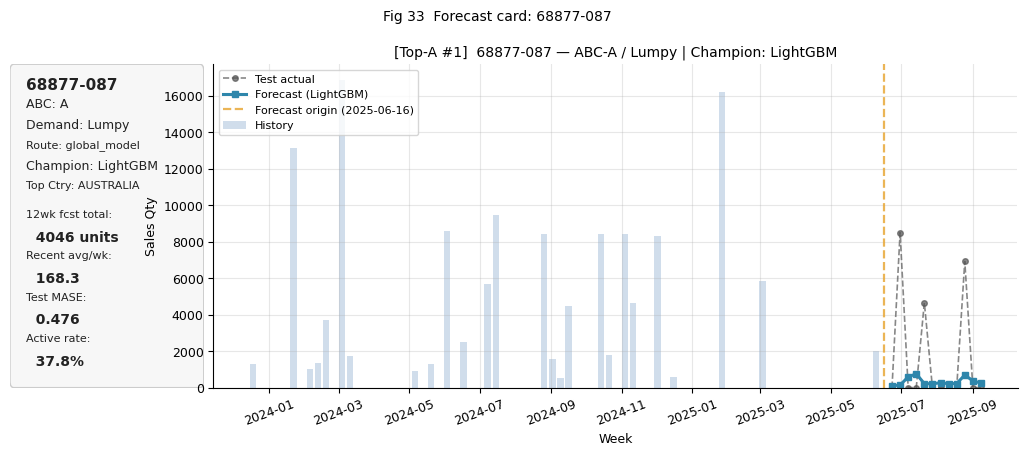

Fig 33 saved → 33_card_68877_087.png


/var/folders/3v/dx_sq5d11y1crmvldlw8s_940000gn/T/ipykernel_52235/888006256.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


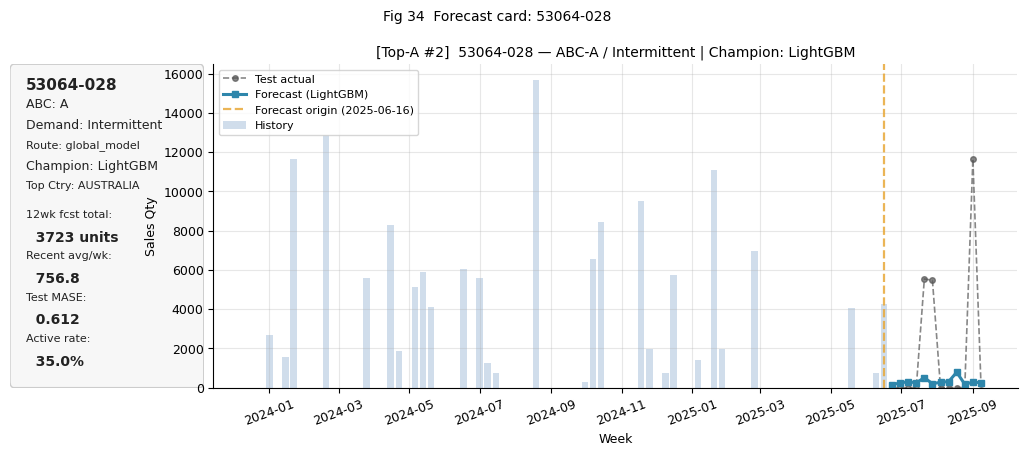

Fig 34 saved → 34_card_53064_028.png


/var/folders/3v/dx_sq5d11y1crmvldlw8s_940000gn/T/ipykernel_52235/888006256.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


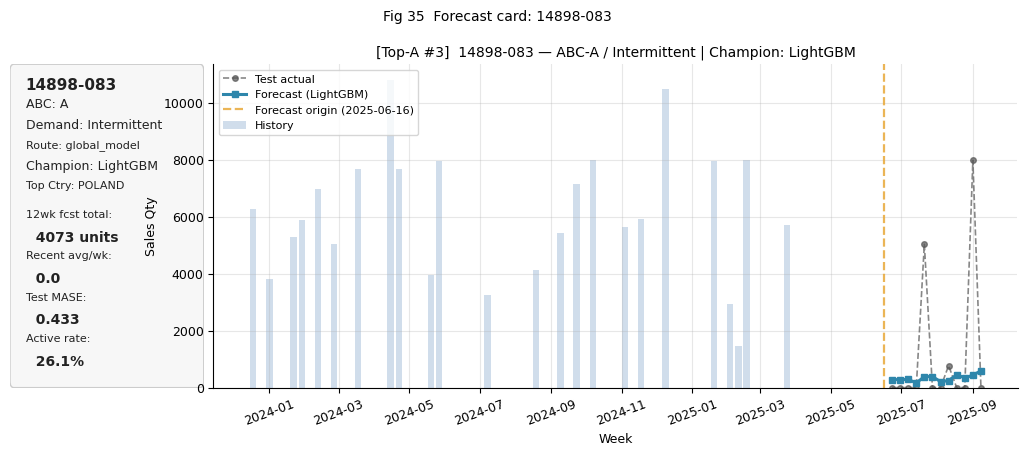

Fig 35 saved → 35_card_14898_083.png


/var/folders/3v/dx_sq5d11y1crmvldlw8s_940000gn/T/ipykernel_52235/888006256.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


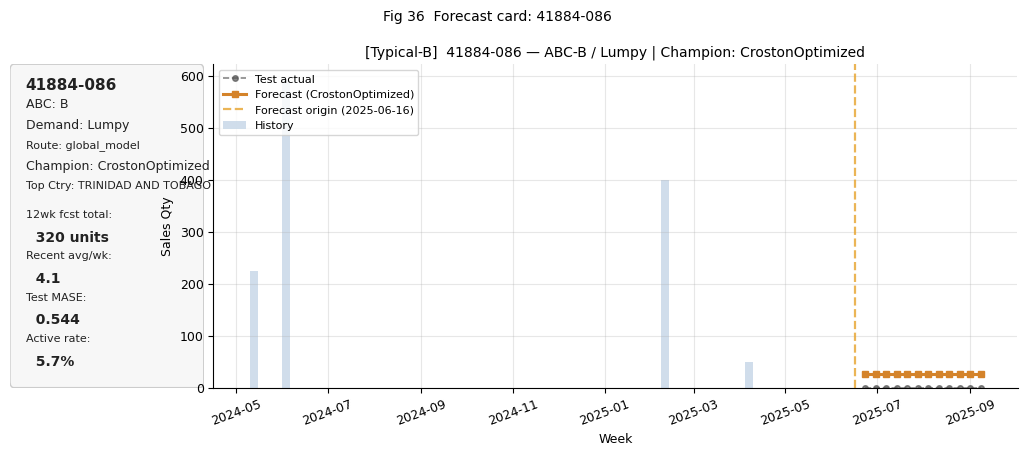

Fig 36 saved → 36_card_41884_086.png


/var/folders/3v/dx_sq5d11y1crmvldlw8s_940000gn/T/ipykernel_52235/888006256.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


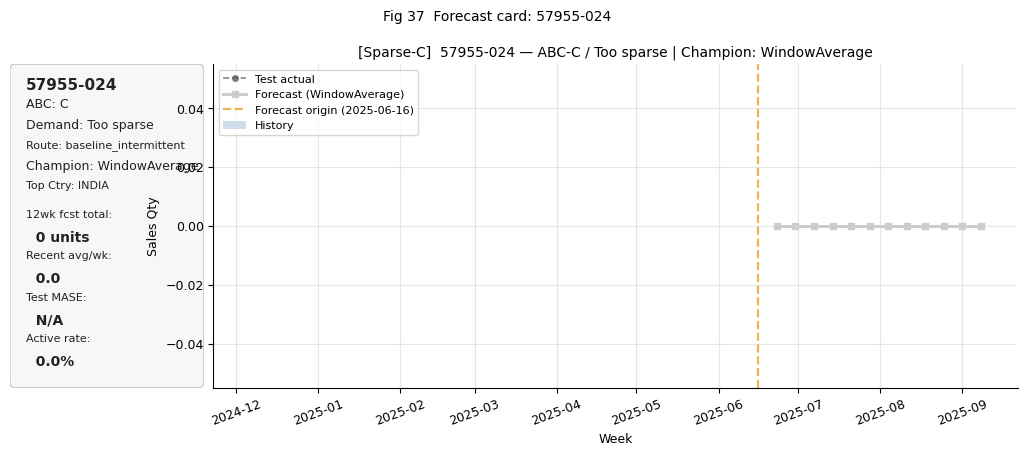

Fig 37 saved → 37_card_57955_024.png


/var/folders/3v/dx_sq5d11y1crmvldlw8s_940000gn/T/ipykernel_52235/888006256.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


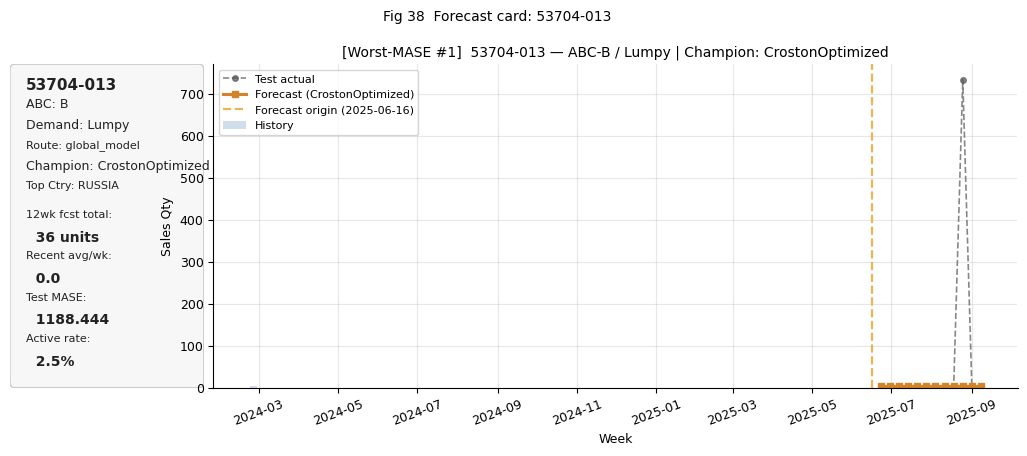

Fig 38 saved → 38_card_53704_013.png


/var/folders/3v/dx_sq5d11y1crmvldlw8s_940000gn/T/ipykernel_52235/888006256.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


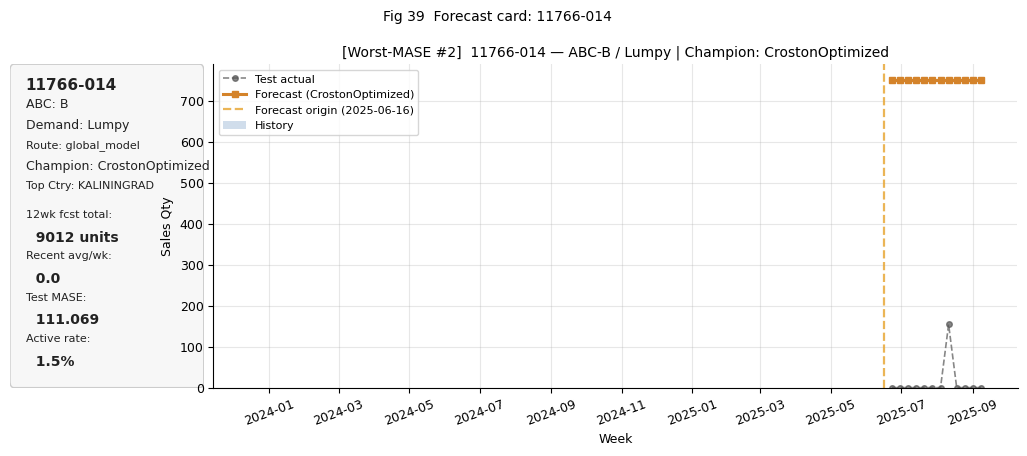

Fig 39 saved → 39_card_11766_014.png


In [8]:
# ── Generate forecast cards — Top 3 A-class + Typical B + Sparse C + 2 Worst ──
for fig_num, (pid, label) in enumerate(zip(card_products, card_labels), start=33):
    plot_card(pid, label, fig_num)

In [9]:
# ── Summary stats of the results table ────────────────────────────────────────
print("results_by_product summary")
print(f"Total products: {len(results):,}")
print(f"With served forecast: "
      f"{results['fcst_12wk_total'].notna().sum():,}")
print(f"With test_mase:       "
      f"{results['test_mase'].notna().sum():,}")
print()
print("fcst_12wk_total distribution by ABC class:")
print(
    results.groupby("abc_class")["fcst_12wk_total"]
    .describe(percentiles=[0.25, 0.5, 0.75])
    .round(1)
    .to_string()
)
print()
print("test_mase distribution by ABC class:")
print(
    results.groupby("abc_class")["test_mase"]
    .describe(percentiles=[0.25, 0.5, 0.75])
    .round(4)
    .to_string()
)
print()
print(f"Forecast file: {csv_path}")

results_by_product summary
Total products: 13,707
With served forecast: 12,954
With test_mase:       12,223

fcst_12wk_total distribution by ABC class:
               count     mean       std    min     25%      50%      75%        max
abc_class                                                                          
A           674.0000 551.3000 1078.6000 0.0000 60.8000 195.2000 526.3000  9742.8000
B          1970.0000 193.4000 1079.6000 0.0000 16.2000  41.0000  91.2000 25416.0000
C         10310.0000   3.4000    8.2000 0.0000  0.0000   0.0000   2.8000   157.9000

test_mase distribution by ABC class:
              count   mean     std    min    25%    50%    75%       max
abc_class                                                               
A          668.0000 0.5639  0.8535 0.0000 0.0740 0.4250 0.7729   11.3821
B         1934.0000 1.9567 27.6133 0.0000 0.2055 0.5433 1.0321 1188.4444
C         9621.0000 0.4557  4.7075 0.0000 0.0000 0.0000 0.3260  389.4458

Forecast file: /Users/ne